In [3]:
import seaborn as sns
import seaborn as sns
import matplotlib.pyplot as pyplotimport
import pandas as pd

# print head
df = pd.read_csv('golub.csv')
print(df.shape)
df.head()

(72, 7135)


,Samples,BM.PB,Gender,Source,tissue.mf,cancer,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
0,39,BM,F,DFCI,BM:f,allB,-1363.276427,-1058.585495,-541.469194,74.349803,...,-35.081447,1565.618803,-485.680714,-170.261227,-919.114293,1675.050053,389.769289,-526.449219,-268.963924,-779.643092
1,40,BM,F,DFCI,BM:f,allB,-796.285053,-1167.103365,7.538493,83.544731,...,-404.737767,622.498054,-1275.354673,214.828233,-750.220666,-441.589276,9.841713,-671.911209,-671.911209,-644.272577
2,42,BM,F,DFCI,BM:f,allB,-679.139168,-1069.832308,-690.301829,-112.075981,...,193.780934,162.525483,-692.534361,517.498108,-674.674103,1265.396405,-65.192805,-714.859684,3672.066149,-822.021231
3,47,BM,M,DFCI,BM:m,allB,-1164.400197,-1109.939891,-990.127218,-238.574994,...,-256.002292,-31.625831,-621.975549,-458.594630,-630.689198,937.767618,-264.715941,-635.046022,475.944222,-794.070116
4,48,BM,F,DFCI,BM:f,allB,-1299.653758,-1401.998536,-1077.543813,-437.344560,...,-509.203660,383.591216,-905.517483,-36.675640,-1116.739685,316.087213,-210.879518,-953.423549,-291.448812,-1057.945876


In [4]:
df['cancer'].value_counts()

,count
cancer,
allB,38
aml,25
allT,9


Load the golub.csv dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable.

In [5]:
mapper = {'allB':0,
          'allT':0,
          'aml':1}

df['y'] = df['cancer'].map(mapper)
genes = df.drop(['Samples',
                 'BM.PB',
                 'Gender',
                 'Source',
                 'tissue.mf',
                 'cancer',
                 'y'], axis=1)

Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes.

In [6]:
from sklearn.linear_model import LinearRegression
y = df['y']

model = LinearRegression()
model = model.fit(genes,y)

y_hat = model.predict(genes)

In [7]:
resid = y_hat - y
resid.describe()

,y
count,7.200000e+01
mean,-5.396917e-17
std,1.125596e-15
min,-2.553513e-15
25%,-7.494005e-16
50%,0.000000e+00
75%,5.828671e-16
max,2.220446e-15


Training MSE: 1.25e-30


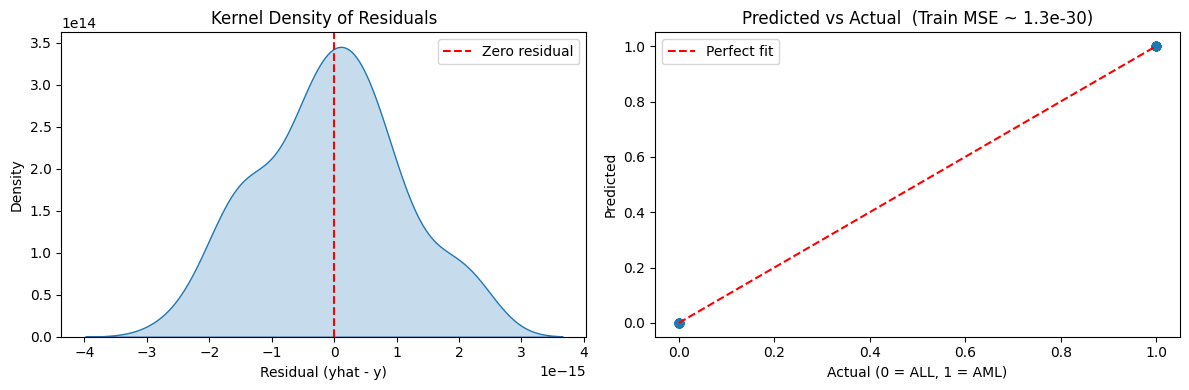

In [8]:
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

mse_train = mean_squared_error(y, y_hat)
print(f'Training MSE: {mse_train:.2e}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# kde of residuals
sns.kdeplot(resid, ax=axes[0], fill=True)
axes[0].axvline(0, color='red', linestyle='--', label='Zero residual')
axes[0].set_xlabel('Residual (yhat - y)')
axes[0].set_ylabel('Density')
axes[0].set_title('Kernel Density of Residuals')
axes[0].legend()

axes[1].scatter(y, y_hat, alpha=0.7)

# predicted vs actuals
axes[1].plot([0, 1], [0, 1], 'r--', label='Perfect fit')
axes[1].set_xlabel('Actual (0 = ALL, 1 = AML)')
axes[1].set_ylabel('Predicted')
axes[1].set_title(f'Predicted vs Actual  (Train MSE ~ {mse_train:.1e})')
axes[1].legend()

plt.tight_layout()
plt.show()

Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

In [9]:
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_mse = -cross_val_score(LinearRegression(), genes, y,
                           scoring='neg_mean_squared_error', cv=kf)

print('5-fold CV MSE per fold:', np.round(cv_mse, 4))
print(f'Mean CV MSE : {cv_mse.mean():.4f}')
print(f'Std  CV MSE : {cv_mse.std():.4f}')
print()
print('Bias-Variance interpretation:')
print(f'  Training MSE ~ {mse_train:.1e}  -> near-zero bias (model memorises training data)')
print(f'  CV MSE       ~ {cv_mse.mean():.4f} -> high variance (poor generalisation)')
print('  With p=7129 predictors and only n=72 observations, OLS is severely')
print('  over-parameterised: it perfectly interpolates the training set (fitting')
print('  noise), so held-out error is ~0.04 -- classic HIGH VARIANCE regime.')

5-fold CV MSE per fold: [0.0454 0.0429 0.0448 0.0469 0.0242]
Mean CV MSE : 0.0408
Std  CV MSE : 0.0084

Bias-Variance interpretation:
  Training MSE ~ 1.3e-30  -> near-zero bias (model memorises training data)
  CV MSE       ~ 0.0408 -> high variance (poor generalisation)
  With p=7129 predictors and only n=72 observations, OLS is severely
  over-parameterised: it perfectly interpolates the training set (fitting
  noise), so held-out error is ~0.04 -- classic HIGH VARIANCE regime.


Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values.

In [10]:
from sklearn.linear_model import LassoCV

alphas = np.logspace(-5, 5, 200)
lasso_cv = LassoCV(alphas=alphas, cv=kf, max_iter=20000, random_state=42)
lasso_cv.fit(genes, y)

coefs      = lasso_cv.coef_
gene_names = np.array(genes.columns)
selected   = gene_names[coefs != 0]
discarded  = gene_names[coefs == 0]

print(f'Optimal alpha : {lasso_cv.alpha_:.4f}')
print(f'Genes kept    : {len(selected)}')
print(f'Genes discarded: {len(discarded)}')
print(f'\nSelected genes:\n{list(selected)}')

Optimal alpha : 121.7383
Genes kept    : 31
Genes discarded: 7098

Selected genes:
['HG3549-HT3751_at', 'J04164_at', 'L38941_at', 'M11147_at', 'M11722_at', 'M17733_at', 'M19507_at', 'M26602_at', 'M27891_at', 'M33680_at', 'M63138_at', 'M91036_rna1_at', 'M96326_rna1_at', 'U14968_at', 'X17042_at', 'X78992_at', 'Z70759_at', 'L06797_s_at', 'D49824_s_at', 'M25079_s_at', 'X57351_s_at', 'V00594_s_at', 'U05255_s_at', 'X03689_s_at', 'M14328_s_at', 'M14483_rna1_s_at', 'M26708_s_at', 'Y00787_s_at', 'Z19554_s_at', 'X56681_s_at', 'HG2887-HT3031_at']


Make a plot that shows the cross validated MSE as $alpha$ varies.

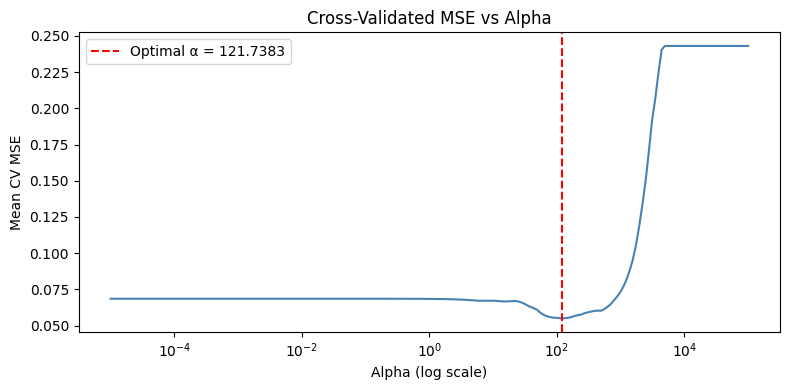

In [11]:
# MSE vs alpha plot
mse_path = lasso_cv.mse_path_.mean(axis=1)

plt.figure(figsize=(8, 4))
plt.semilogx(lasso_cv.alphas_, mse_path, color='steelblue')
plt.axvline(lasso_cv.alpha_, color='red', linestyle='--', label=f'Optimal α = {lasso_cv.alpha_:.4f}')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Mean CV MSE')
plt.title('Cross-Validated MSE vs Alpha')
plt.legend()
plt.tight_layout()
plt.show()

For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?
- Lasso is overfitting when $\alpha$ is less than 10, and underfitting when $\alpha$ is greater than 200.
The best hyperparameter is $\alpha = 121.7383$.

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.
- Linear regression overfits the data including the noisy ones. LASSO sacrifices a little training accuracy to build a more generalizable model.
7. Why do regularization methods lend themselves to scenarios like precision health?
- Precision health data contains way too many features that could more easily make the model overfitting. Regularization can reduce overfitting and build a more general model.
8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?
- Correlation does not always mean causation.
- In precision health questions, features, such as genes, are highly associated. LASSO tends to arbitrarily select only one variable from a group of correlated predictors and ignore the others, causing instability.